Modules loaded - starting analytical summer solstice method

Spinning up model for 15 lunar days at -88.5°S...
Summer Solstice Dawn identified! Pre-scoop 4cm temp: 89.8 K
Starting Mission Temperature of newly exposed surface: 89.9 K

Simulating fully vectorized physical cooling over 60 days...

[SUCCESS] Plot automatically saved as: Annotated_Cooling_60d_Lat88.5S_YrDay173_d4cm_D50cm_PSR_Floor.png


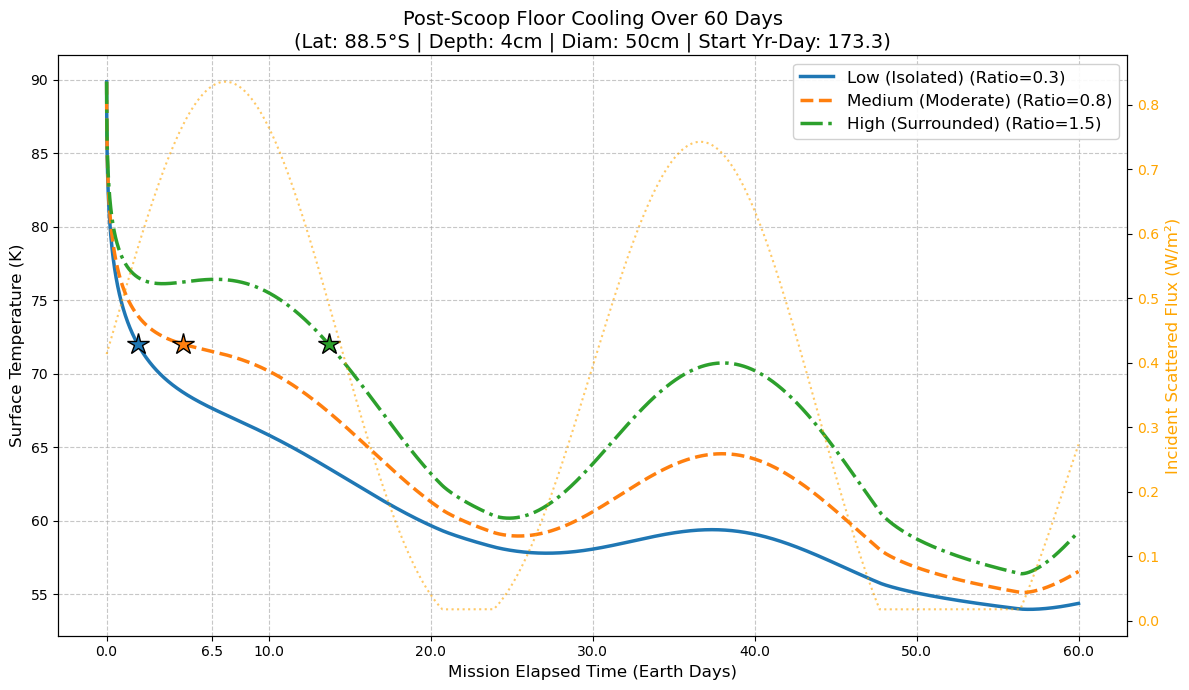


--- Mission Cooling Summary (Full Run) ---
Low (Isolated)      : Started 89.9 K -> Ended 54.4 K
Medium (Moderate)   : Started 89.9 K -> Ended 56.5 K
High (Surrounded)   : Started 89.9 K -> Ended 59.3 K

--- Temperature at Specified Target Time (6.5 Days) ---
Low (Isolated)      : 67.6 K
Medium (Moderate)   : 71.5 K
High (Surrounded)   : 76.4 K


In [1]:
import sys
import subprocess
import numpy as np
import copy
import matplotlib.pyplot as plt

# ==========================================
# AUTO-INSTALL heat1d IF MISSING
# ==========================================
try:
    from heat1d import Model, Configurator, planets
except ImportError:
    print("[INFO] 'heat1d' module not found. Automatically installing from GitHub...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "git+https://github.com/phayne/heat1d.git"])
    print("[INFO] Installation complete. Loading module...")
    from heat1d import Model, Configurator, planets

# Patch for older heat1d compatibility with newer numpy 2.0+
if not hasattr(np, 'float'): np.float = float
if not hasattr(np, 'int'): np.int = int

print("Modules loaded - starting analytical summer solstice method")

# ==========================================
# 0. USER CONFIGURATION
# ==========================================
actual_lat_deg = -88.5           # Latitude (degrees South)
excavation_depth = 0.04          # Depth of scoop (meters)
crater_diameter = 0.5            # Diameter of scoop (meters)
mission_days_earth = 60          # Total duration of the simulation (Earth days)
target_query_day = 6.5           # Exact day to query temperatures (Earth days)

depth_to_diameter = excavation_depth / crater_diameter

# ==========================================
# 1. Lucey/Ingersoll Functions 
# ==========================================
def lucey_thermal_model_fixed_ratio(S, psr_albedo, emissivity, f_shape, solar_elev_rad, 
                                  wall_albedo=0.16, fixed_thermal_ratio=0.8):
    sigma = 5.67e-8
    reflected_component = S * np.sin(solar_elev_rad) * wall_albedo * f_shape
    thermal_emission = reflected_component * fixed_thermal_ratio
    return thermal_emission

def lucey_ingersoll_fixed_ratio(S, psr_albedo, emissivity, depth_to_diameter_ratio, 
                              latitude_deg, hour_angle, year_fraction, 
                              wall_albedo=0.16, planet_obliquity=1.54, thermal_ratio=0.8):
    h_D = depth_to_diameter_ratio
    alpha = np.arccos(1 - 2 * h_D)
    f_shape = (1 - np.cos(alpha)) / 2
    ha_rad = np.radians(hour_angle)
    
    # DYNAMIC DECLINATION: Calculates true declining sun angle as we move away from solstice
    orbital_position = 2 * np.pi * year_fraction
    dec_rad = np.arcsin(np.sin(np.radians(planet_obliquity)) * np.cos(orbital_position))
    
    sin_elev = np.sin(np.radians(latitude_deg)) * np.sin(dec_rad) + \
               np.cos(np.radians(latitude_deg)) * np.cos(dec_rad) * np.cos(ha_rad)
    solar_elev_rad = np.arcsin(max(0, sin_elev))
    solar_elev_deg = np.degrees(solar_elev_rad)
    
    if solar_elev_deg <= 0:
        return {'total_flux': 0, 'reflected_flux': 0, 'thermal_emission': 0}
    
    r = psr_albedo
    f_1 = f_shape * np.sin(solar_elev_rad)**2 / np.pi
    multiple_reflection_factor = 1 / (1 - r * f_shape)
    reflected_flux = S * (1 - r) * f_1 * multiple_reflection_factor
    
    thermal_emission = lucey_thermal_model_fixed_ratio(
        S, psr_albedo, emissivity, f_shape, solar_elev_rad, wall_albedo, thermal_ratio)
    
    return {
        'total_flux': reflected_flux + thermal_emission,
        'reflected_flux': reflected_flux,
        'thermal_emission': thermal_emission
    }

# ==========================================
# 2. Setup & Find True Summer Solstice
# ==========================================
lat_rad = np.deg2rad(actual_lat_deg)

config = Configurator()
config.m = 20  
config.n = 10  
standard_moon = copy.deepcopy(planets.Moon)

# Spin up
print(f"\nSpinning up model for 15 lunar days at {actual_lat_deg}°S...")
m_spinup = Model(planet=standard_moon, lat=lat_rad, ndays=15, config=config)
m_spinup.run()

depth_profile = m_spinup.profile.z
depth_idx = np.argmin(np.abs(depth_profile - excavation_depth))
surface_temps = m_spinup.T[:, 0]
local_times = m_spinup.lt

# First, determine how many computational steps are in one lunar day
steps_per_lunar_day = len(local_times) // 15

# Find Peak Summer (Ignore the first 3 lunar days to bypass thermal transients)
transient_cutoff = steps_per_lunar_day * 3
peak_summer_noon_idx = transient_cutoff + np.argmax(surface_temps[transient_cutoff:])

# Calculate Dawn (1/4 of a lunar day before noon)
steps_back_to_dawn = steps_per_lunar_day // 4
landing_idx = peak_summer_noon_idx - steps_back_to_dawn 

# Force the mission to start exactly at the Southern Summer Solstice
landing_earth_day = 346.6 / 2.0

print(f"Summer Solstice Dawn identified! Pre-scoop {excavation_depth*100:.0f}cm temp: {m_spinup.T[landing_idx, depth_idx]:.1f} K")

# ==========================================
# Execute the scoop (Using Physical Spatial Interpolation)
# ==========================================
pre_scoop_profile = m_spinup.T[landing_idx, :]
z_physical_scooped = depth_profile + excavation_depth
post_scoop_profile = np.interp(z_physical_scooped, depth_profile, pre_scoop_profile)

print(f"Starting Mission Temperature of newly exposed surface: {post_scoop_profile[0]:.1f} K")

# ==========================================
# 3. Vectorized Manual Cooling Simulation
# ==========================================
dt_seconds = 2.0  
steps = int((mission_days_earth * 24 * 3600) / dt_seconds)
time_array_days = np.arange(steps) * dt_seconds / (24 * 3600)

thermal_ratios = [
    {'name': 'Low (Isolated)', 'ratio': 0.3},
    {'name': 'Medium (Moderate)', 'ratio': 0.8},
    {'name': 'High (Surrounded)', 'ratio': 1.5}
]

mission_results = []
start_hour_angle = -90.0  
lunar_day_seconds = 29.53 * 24 * 3600

# Physical constants for the explicit step / Cryogenic temperatures
rho = 1500.0  # Bulk density at 4-10cm 
c_p = 190.0   # Avg specific heat for 60-90K window 
k = 0.005     # Solid thermal conductivity
emissivity = 0.95 
sigma = 5.67e-8

z = depth_profile
dz_up = z[1:-1] - z[:-2]       
dz_dn = z[2:] - z[1:-1]        
dz_cell = (z[2:] - z[:-2]) / 2.0 
dz_surface = z[1] - z[0]       

print(f"\nSimulating fully vectorized physical cooling over {mission_days_earth} days...")

for ratio_dict in thermal_ratios:
    ratio = ratio_dict['ratio']
    flux_array = np.zeros(steps)
    mission_temps = np.zeros(steps)
    
    T = np.copy(post_scoop_profile)
    
    for i in range(steps):
        t_seconds = i * dt_seconds
        
        current_earth_day = landing_earth_day + (t_seconds / 86400.0)
        current_year_fraction = current_earth_day / 346.6
        current_ha = start_hour_angle + ((t_seconds / lunar_day_seconds) * 360)
        
        flux_res = lucey_ingersoll_fixed_ratio(
            S=standard_moon.S, psr_albedo=0.16, emissivity=emissivity, 
            depth_to_diameter_ratio=depth_to_diameter, latitude_deg=actual_lat_deg, 
            hour_angle=current_ha, year_fraction=current_year_fraction, thermal_ratio=ratio
        )
        total_boundary_flux = flux_res['total_flux'] + standard_moon.Qb
        flux_array[i] = total_boundary_flux
        
        conduction_up = k * (T[1] - T[0]) / dz_surface
        radiation = emissivity * sigma * (T[0]**4)
        net_surface_flux = total_boundary_flux + conduction_up - radiation
        dT_surface = (net_surface_flux * dt_seconds) / (rho * c_p * (dz_surface / 2.0))
        
        q_in = k * (T[:-2] - T[1:-1]) / dz_up
        q_out = k * (T[1:-1] - T[2:]) / dz_dn
        dT_subsurface = ((q_in - q_out) * dt_seconds) / (rho * c_p * dz_cell)
        
        T[0] += dT_surface
        T[1:-1] += dT_subsurface
        
        mission_temps[i] = T[0]
        
    mission_results.append({
        'name': ratio_dict['name'],
        'ratio': ratio,
        'temps': mission_temps,
        'flux': flux_array
    })

# ==========================================
# 4. Plot, Annotate & Auto-Save Results
# ==========================================
fig, ax1 = plt.subplots(figsize=(12, 7))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] 
for i, res in enumerate(mission_results):
    ax1.plot(time_array_days, res['temps'], 
             linestyle=['-', '--', '-.'][i], 
             linewidth=2.5, color=colors[i],
             label=f"{res['name']} (Ratio={res['ratio']})")

target_temp = 72.0 
for i, res in enumerate(mission_results):
    temps = res['temps']
    if np.any(temps < target_temp):
        cross_idx = np.argmax(temps < target_temp) 
        t_cross = time_array_days[cross_idx]
        ax1.plot(t_cross, target_temp, marker='*', markersize=16, color=colors[i], 
                 markeredgecolor='black', zorder=5)

ax1.set_xlabel('Mission Elapsed Time (Earth Days)', fontsize=12)
ax1.set_ylabel('Surface Temperature (K)', fontsize=12)

plot_title = (f'Post-Scoop Floor Cooling Over {mission_days_earth} Days\n'
              f'(Lat: {abs(actual_lat_deg):.1f}°S | '
              f'Depth: {excavation_depth*100:.0f}cm | Diam: {crater_diameter*100:.0f}cm | '
              f'Start Yr-Day: {landing_earth_day:.1f})')
ax1.set_title(plot_title, fontsize=14)

ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend(loc='upper right', fontsize=12, framealpha=0.9)

# Add Custom X-Axis Tick for User-Defined Target Day
xticks = list(ax1.get_xticks())
if target_query_day not in xticks:
    xticks.append(target_query_day)
    xticks.sort()
ax1.set_xticks(xticks)

for tick in ax1.xaxis.get_major_ticks():
    if np.isclose(tick.get_loc(), target_query_day):
        tick.label1.set_color('red')
        tick.label1.set_fontweight('bold')

ax2 = ax1.twinx()
ax2.plot(time_array_days, mission_results[1]['flux'], color='orange', linestyle=':', alpha=0.6, label='Moderate Ratio Flux')
ax2.set_ylabel('Incident Scattered Flux (W/m²)', color='orange', fontsize=12)
ax2.tick_params(axis='y', labelcolor='orange')

plt.tight_layout()

# Save logic
file_season = f"YrDay{landing_earth_day:.0f}"
file_lat = f"Lat{abs(actual_lat_deg):.1f}S"
file_dims = f"d{excavation_depth*100:.0f}cm_D{crater_diameter*100:.0f}cm"
filename = f"Annotated_Cooling_{mission_days_earth}d_{file_lat}_{file_season}_{file_dims}_PSR_Floor.png"

plt.savefig(filename, dpi=300, bbox_inches='tight')
print(f"\n[SUCCESS] Plot automatically saved as: {filename}")
plt.show()

# Print Summary
print("\n--- Mission Cooling Summary (Full Run) ---")
for res in mission_results:
    print(f"{res['name']:<20}: Started {res['temps'][0]:.1f} K -> Ended {res['temps'][-1]:.1f} K")

print(f"\n--- Temperature at Specified Target Time ({target_query_day} Days) ---")
query_idx = np.argmin(np.abs(time_array_days - target_query_day))
for res in mission_results:
    temp_at_target = res['temps'][query_idx]
    print(f"{res['name']:<20}: {temp_at_target:.1f} K")